In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_regression

In [4]:
X,y = make_regression(n_samples=4, n_features=1, n_informative=1, n_targets=1,noise=80,random_state=13)

In [5]:
X, y

(array([[-0.71239066],
        [ 0.45181234],
        [-0.04450308],
        [ 0.75376638]]),
 array([  7.21786552,  16.04609925, -27.83756166, 144.36688189]))

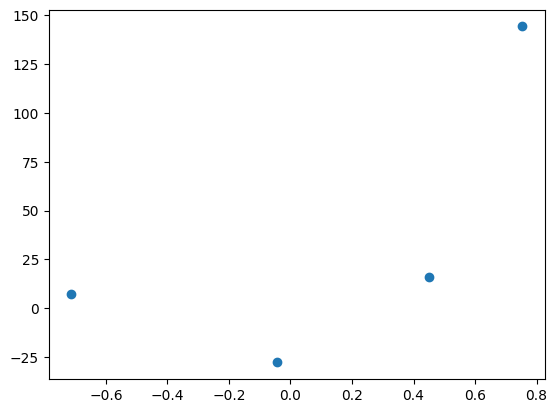

In [50]:
plt.scatter(X,y)

In [51]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(X,y)
lr.coef_, lr.intercept_

(array([78.35063668]), np.float64(26.15963284313262))

In [66]:
#Iteration 1
# y_pred = mx+b    now we take a constant m=78.3
b = 100
y_pred = ((78.35*X)+b).reshape(4)    #Take intially zero

In [67]:
y_pred

array([ 44.18419163, 135.39949674,  96.51318381, 159.05759577])

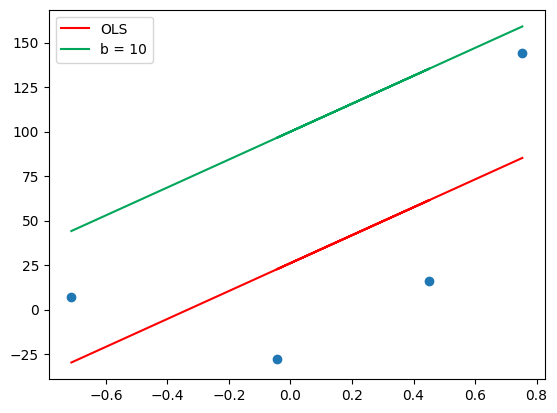

In [68]:
plt.scatter(X,y)
plt.plot(X,lr.predict(X),color='red',label='OLS')
plt.plot(X,y_pred,color='#00a65a',label='b = 10')
plt.legend()
plt.show()

In [69]:
#finding a slop
loss_slop = -2*np.sum(y-(78.35*X.ravel())-b)

In [70]:
loss_slop

np.float64(590.7223659179078)

In [71]:
#learning rate 
l = 0.1

In [72]:
step_size = loss_slop*l
step_size

np.float64(59.072236591790784)

In [73]:
b = b-step_size

In [74]:
b

np.float64(40.927763408209216)

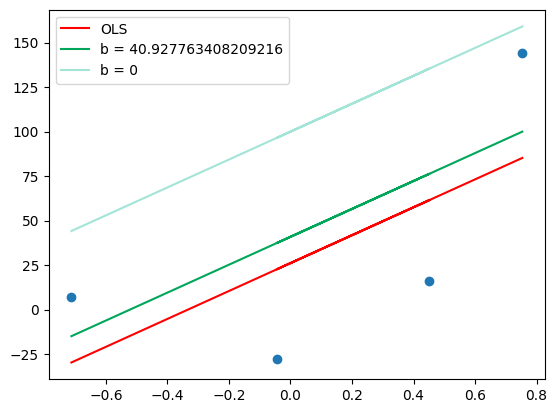

In [75]:
y_pred1 = ((78.35 * X) + b).reshape(4)

plt.scatter(X,y)
plt.plot(X,lr.predict(X),color='red',label='OLS')
plt.plot(X,y_pred1,color='#00a65a',label='b = {}'.format(b))
plt.plot(X,y_pred,color='#A3E4D7',label='b = 0')
plt.legend()
plt.show()

In [76]:
# Let's do iterative 

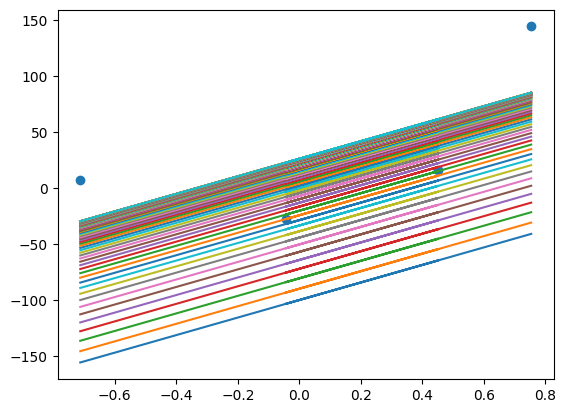

In [82]:
m = 78.35
b = -100
epoc = 100
lr = 0.01

for i in range(epoc):
    y_pred = m * X + b
    loss_slop = -2*np.sum(y-(m*X.ravel())-b)
    b = b-(lr*loss_slop)
    plt.plot(X, y_pred)
plt.scatter(X, y)
plt.show()

# Let's create our own class and compare with sklearn class

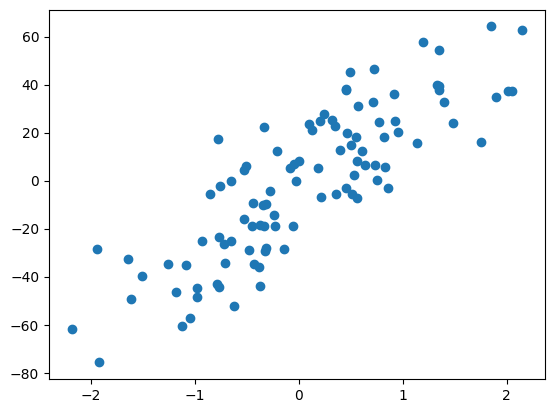

In [83]:
from sklearn.datasets import make_regression
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import cross_val_score

X,y = make_regression(n_samples=100, n_features=1, n_informative=1, n_targets=1,noise=20,random_state=13)

plt.scatter(X,y)

In [84]:
from sklearn.linear_model import LinearRegression
rig = LinearRegression()

In [85]:
rig.fit(X, y)

LinearRegression()

In [86]:
rig.coef_, rig.intercept_

(array([27.82809103]), np.float64(-2.29474455867698))

In [92]:
class Gradient_discent:
    def __init__(self, lr, epocs):
        self.m = 100
        self.b = -120
        self.lr = lr
        self.epocs = epocs
    def fit(self, X, y):
        for i in range(epoc):
            loss_slope_b = -2 * np.sum(y - self.m*X.ravel() - self.b)
            loss_slope_m = -2 * np.sum((y - self.m*X.ravel() - self.b)*X.ravel())
            
            self.b = self.b - (self.lr * loss_slope_b)
            self.m = self.m - (self.lr * loss_slope_m)
        print(self.m,self.b)
        
    def predict(self,X):
        return self.m * X + self.b       

In [97]:
Gr = Gradient_discent(0.001, 100)

In [98]:
Gr.fit(X, y)

27.828091872608653 -2.2947448944994893
